In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 1. Global setting
# ============================================================
omega = np.array([0.5, 1.0, 1.0])   # fixed policy (w1, w2, w3)

A = -1.0
B = 1.0
sigma = 1.0

M = 1.0
N_cost = 1.0
lambda_reg = 0.1

ridge = 0


# ============================================================
# 2. Exact discrete-time coefficients
# ============================================================
def exact_discrete_coeffs(dt, A=-1.0, B=1.0, sigma=1.0):
    """
    Exact one-step discretization for:
        ds_t = (A s_t + B a_t) dt + sigma dW_t

    Returns
    -------
    expA : float
        e^{A dt}
    G_a : float
        coefficient before action in exact one-step transition
    var_noise : float
        variance of exact one-step Gaussian noise
    A_t : float
        effective drift coefficient divided by dt
    B_t : float
        effective control coefficient divided by dt
    sigma_t2 : float
        var_noise / dt
    """
    if abs(A) < 1e-12:
        expA = 1.0
        G_a = B * dt
        var_noise = sigma**2 * dt
        A_t = 1.0
        B_t = B
        sigma_t2 = sigma**2
    else:
        expA = np.exp(A * dt)
        G_a = B * (expA - 1.0) / A
        var_noise = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A)
        A_t = (expA - 1.0) / dt
        B_t = G_a / dt
        sigma_t2 = var_noise / dt

    return expA, G_a, var_noise, A_t, B_t, sigma_t2


# ============================================================
# 3. Fixed Gaussian policy
# ============================================================
def sample_action(s, rng, omega):
    """
    a | s ~ N(w1*s + w2, w3^2)
    """
    w1, w2, w3 = omega
    mean = w1 * s + w2
    return mean + w3 * rng.normal(size=np.shape(s))


def log_gaussian_policy(a, s, omega):
    """
    log pi(a|s) for Gaussian policy N(w1*s+w2, w3^2)
    """
    w1, w2, w3 = omega
    mean = w1 * s + w2
    return -0.5 * np.log(2.0 * np.pi) - np.log(w3) - 0.5 * ((a - mean) / w3) ** 2


In [3]:
# ============================================================
# 4. Exact coefficients under fixed omega
# ============================================================
def fixed_policy_coeffs_phibe(dt, beta, omega, A=-1.0, B=1.0, sigma=1.0,
                              M=1.0, N_cost=1.0, lambda_reg=0.1):
    """
    PhiBE fixed-policy coefficients.

    For fixed Gaussian policy omega=(w1,w2,w3), the PhiBE value function is
        V^omega_phi(s) = 1/2 k2 s^2 + k1 s + k0

    using effective coefficients A_t, B_t, sigma_t^2.
    """
    w1, w2, w3 = omega

    _, _, _, A_t, B_t, sigma_t2 = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    denom2 = beta - 2.0 * (A_t + B_t * w1)
    denom1 = beta - (A_t + B_t * w1)

    if denom2 <= 0:
        raise ValueError("Need beta - 2(A_t + B_t w1) > 0 for stability.")
    if denom1 <= 0:
        raise ValueError("Need beta - (A_t + B_t w1) > 0 for stability.")

    k2 = -(M + N_cost * w1**2) / denom2
    k1 = (B_t * w2 * k2 - N_cost * w1 * w2) / denom1
    k0 = (
        -0.5 * N_cost * (w2**2 + w3**2)
        + lambda_reg * (0.5 * np.log(2.0 * np.pi) + np.log(w3) + 0.5)
        + B_t * w2 * k1
        + 0.5 * sigma_t2 * k2
    ) / beta

    return k2, k1, k0

def value_true_fixed_policy_phibe(s, dt, beta, omega, A=-1.0, B=1.0, sigma=1.0,
                                  M=1.0, N_cost=1.0, lambda_reg=0.1):
    k2, k1, k0 = fixed_policy_coeffs_phibe(
        dt=dt, beta=beta, omega=omega, A=A, B=B, sigma=sigma,
        M=M, N_cost=N_cost, lambda_reg=lambda_reg
    )
    return 0.5 * k2 * s**2 + k1 * s + k0

In [4]:
# ============================================================
# 5. Convert to one-dimensional scalar parameterization
# ============================================================
def one_dim_structure_constants_phibe(dt, beta, omega, A=-1.0, B=1.0, sigma=1.0,
                                      M=1.0, N_cost=1.0, lambda_reg=0.1):
    """
    For the PhiBE fixed-policy value function:
        V(s) = theta * phi(s) + r(s),
    where theta = k2 and
        k1 = a*k2 + b,
        k0 = c*k2 + d.
    """
    w1, w2, w3 = omega
    _, _, _, A_t, B_t, sigma_t2 = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    denom1 = beta - (A_t + B_t * w1)
    if denom1 <= 0:
        raise ValueError("Need beta - (A_t + B_t w1) > 0.")

    a = (B_t * w2) / denom1
    b = -(N_cost * w1 * w2) / denom1

    c = (B_t * w2 * a + 0.5 * sigma_t2) / beta
    d = (
        -0.5 * N_cost * (w2**2 + w3**2)
        + lambda_reg * (0.5 * np.log(2.0 * np.pi) + np.log(w3) + 0.5)
        + B_t * w2 * b
    ) / beta

    return a, b, c, d


def basis_1d(s, a, c):
    """
    phi(s) = 1/2 s^2 + a s + c
    """
    return (0.5 * s**2 + a * s + c).reshape(-1, 1)


def basis_1d_prime(s, a, c):
    """
    phi'(s) = s + a
    """
    return (s + a).reshape(-1, 1)


def basis_1d_second(s, a, c):
    """
    phi''(s) = 1
    """
    return np.ones_like(s).reshape(-1, 1)


def r_known(s, b, d):
    """
    r(s) = b s + d
    """
    return b * s + d


def r_known_prime(s, b, d):
    """
    r'(s) = b
    """
    return b * np.ones_like(s)


def value_from_theta_1d(s, theta, a, b, c, d):
    """
    V_theta(s) = theta * phi(s) + r(s)
               = theta * (1/2 s^2 + a s + c) + (b s + d)
    """
    return theta * (0.5 * s**2 + a * s + c) + (b * s + d)

In [5]:
# ============================================================
# 6. Simulate on-policy data
# ============================================================
def simulate_on_policy_data(
    N_sample,
    dt,
    omega,
    A=-1.0,
    B=1.0,
    sigma=1.0,
    s0=0.0,
    burn_in=300,
    seed=0,
):
    """
    Generate one long on-policy trajectory after burn-in.

    Returns
    -------
    s_list, a_list, s_next_list : arrays of shape (N_sample,)
    """
    rng = np.random.default_rng(seed)

    expA, G_a, var_noise, _, _, _ = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    s = float(s0)

    # burn-in
    for _ in range(burn_in):
        a = sample_action(s, rng, omega)
        eps = rng.normal(loc=0.0, scale=np.sqrt(var_noise))
        s = expA * s + G_a * a + eps

    s_list = np.zeros(N_sample)
    a_list = np.zeros(N_sample)
    s_next_list = np.zeros(N_sample)

    for i in range(N_sample):
        a = sample_action(s, rng, omega)
        eps = rng.normal(loc=0.0, scale=np.sqrt(var_noise))
        s_next = expA * s + G_a * a + eps

        s_list[i] = s
        a_list[i] = a
        s_next_list[i] = s_next

        s = s_next

    return s_list, a_list, s_next_list

In [6]:
# ============================================================
# 7. PhiBE one-dimensional estimator
# ============================================================
def fit_theta_phibe_sample_1d(
    s, a, s_next, dt, beta, omega,
    A=-1.0, B=1.0, sigma=1.0,
    M=1.0, N_cost=1.0, lambda_reg=0.1,
    ridge=1e-10,
    include_diffusion=False,
):
    """
    Fit one scalar theta in the parameterization:
        V(s) = theta * phi(s) + r(s)

    Important:
    We must subtract the known part r(s) from the Bellman equation.

    Operator used:
        beta V - ((s_next - s)/dt) V'(s)
    and optionally - 0.5 sigma_t2 V''(s), if include_diffusion=True

    Returns
    -------
    theta_hat : float
    """
    a_coef, b_coef, c_coef, d_coef = one_dim_structure_constants_phibe(
        dt=dt, beta=beta, omega=omega, A=A, B=B, sigma=sigma,
        M=M, N_cost=N_cost, lambda_reg=lambda_reg
    )

    phi = basis_1d(s, a_coef, c_coef)            # (N,1)
    phi_p = basis_1d_prime(s, a_coef, c_coef)    # (N,1)
    phi_pp = basis_1d_second(s, a_coef, c_coef)  # (N,1)

    r_val = r_known(s, b_coef, d_coef)           # (N,)
    r_p = r_known_prime(s, b_coef, d_coef)       # (N,)

    delta_over_dt = (s_next - s) / dt

    _, _, _, _, _, sigma_t2 = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    # Operator on unknown basis phi
    if include_diffusion:
        L_phi = beta * phi - delta_over_dt[:, None] * phi_p - 0.5 * sigma_t2 * phi_pp
    else:
        L_phi = beta * phi - delta_over_dt[:, None] * phi_p

    # Operator on known part r(s)
    if include_diffusion:
        # r''(s)=0, so diffusion term is zero anyway
        L_r = beta * r_val - delta_over_dt * r_p
    else:
        L_r = beta * r_val - delta_over_dt * r_p

    logp = log_gaussian_policy(a, s, omega)
    reward = -0.5 * M * s**2 - 0.5 * N_cost * a**2 - lambda_reg * logp

    # Regress theta from:
    #   <phi, L_phi>*theta = <phi, reward - L_r>
    A_hat = (phi.T @ L_phi) / len(s)   # shape (1,1)
    b_hat = (phi.T @ (reward - L_r)) / len(s)   # shape (1,)

    theta_hat = np.linalg.solve(A_hat + ridge * np.eye(1), b_hat)[0]
    return theta_hat


# ============================================================
# 8. Exact theta for PhiBE / fixed-policy value
# ============================================================
def theta_true_fixed_policy_phibe(dt, beta, omega, A=-1.0, B=1.0, sigma=1.0,
                                  M=1.0, N_cost=1.0, lambda_reg=0.1):
    k2, _, _ = fixed_policy_coeffs_phibe(
        dt=dt, beta=beta, omega=omega, A=A, B=B, sigma=sigma,
        M=M, N_cost=N_cost, lambda_reg=lambda_reg
    )
    return k2

In [7]:
# ============================================================
# 9. Error computation
# ============================================================
def compute_error_for_one_setting_1d(
    beta,
    dt,
    N_sample,
    omega,
    A=-1.0,
    B=1.0,
    sigma=1.0,
    M=1.0,
    N_cost=1.0,
    lambda_reg=0.1,
    n_rep=20,
    s_eval=None,
    ridge=1e-10,
    include_diffusion=False,
):
    """
    Compare:
        - true fixed-policy value function
        - data-driven one-dimensional fitted value function

    Returns
    -------
    dict with mean/std of function error and theta error
    """
    if s_eval is None:
        s_eval = np.linspace(-4, 4, 1000)

    a_coef, b_coef, c_coef, d_coef = one_dim_structure_constants_phibe(
        dt=dt, beta=beta, omega=omega, A=A, B=B, sigma=sigma,
        M=M, N_cost=N_cost, lambda_reg=lambda_reg
    )

    theta_true = theta_true_fixed_policy_phibe(
        dt=dt, beta=beta, omega=omega, A=A, B=B, sigma=sigma,
        M=M, N_cost=N_cost, lambda_reg=lambda_reg
    )

    V_true_eval = value_from_theta_1d(s_eval, theta_true, a_coef, b_coef, c_coef, d_coef)

    value_errs = []
    theta_errs = []

    for rep in range(n_rep):
        s, a, s_next = simulate_on_policy_data(
            N_sample=N_sample,
            dt=dt,
            omega=omega,
            A=A,
            B=B,
            sigma=sigma,
            s0=0.0,
            burn_in=300,
            seed=rep,
        )

        theta_hat = fit_theta_phibe_sample_1d(
            s=s,
            a=a,
            s_next=s_next,
            dt=dt,
            beta=beta,
            omega=omega,
            A=A,
            B=B,
            sigma=sigma,
            M=M,
            N_cost=N_cost,
            lambda_reg=lambda_reg,
            ridge=ridge,
            include_diffusion=include_diffusion,
        )

        V_hat_eval = value_from_theta_1d(s_eval, theta_hat, a_coef, b_coef, c_coef, d_coef)

        value_err = np.sqrt(np.mean((V_hat_eval - V_true_eval) ** 2))
        theta_err = abs(theta_hat - theta_true)

        value_errs.append(value_err)
        theta_errs.append(theta_err)

    return {
        "beta": beta,
        "dt": dt,
        "N_sample": N_sample,
        "value_error_mean": np.mean(value_errs),
        "value_error_std": np.std(value_errs),
        "theta_error_mean": np.mean(theta_errs),
        "theta_error_std": np.std(theta_errs),
        "theta_true": theta_true,
    }


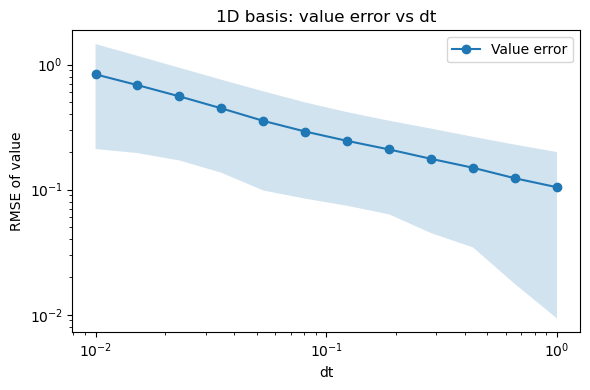

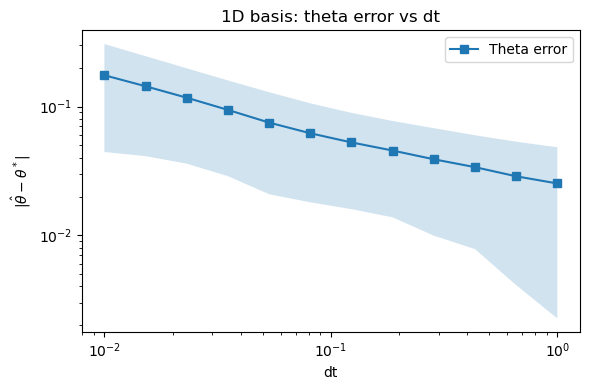

In [8]:
# ============================================================
# 11. Example 2: error vs dt
# ============================================================
dt_grid = np.logspace(-2, 0, 12)
beta_fixed = 1.0
N_fixed = 1000

results_dt = []

for dt_val in dt_grid:
    out = compute_error_for_one_setting_1d(
        beta=beta_fixed,
        dt=dt_val,
        N_sample=N_fixed,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
        n_rep=20,
        ridge=ridge,
        include_diffusion=False,
    )
    results_dt.append(out)

df_dt = pd.DataFrame(results_dt)
#print(df_dt)

plt.figure(figsize=(6, 4))
plt.plot(df_dt["dt"], df_dt["value_error_mean"], marker="o", label="Value error")
plt.fill_between(
    df_dt["dt"],
    df_dt["value_error_mean"] - df_dt["value_error_std"],
    df_dt["value_error_mean"] + df_dt["value_error_std"],
    alpha=0.2,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt")
plt.ylabel("RMSE of value")
plt.title(r"1D basis: value error vs dt")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(df_dt["dt"], df_dt["theta_error_mean"], marker="s", label="Theta error")
plt.fill_between(
    df_dt["dt"],
    df_dt["theta_error_mean"] - df_dt["theta_error_std"],
    df_dt["theta_error_mean"] + df_dt["theta_error_std"],
    alpha=0.2,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt")
plt.ylabel(r"$|\hat\theta-\theta^*|$")
plt.title(r"1D basis: theta error vs dt")
plt.legend()
plt.tight_layout()
plt.show()

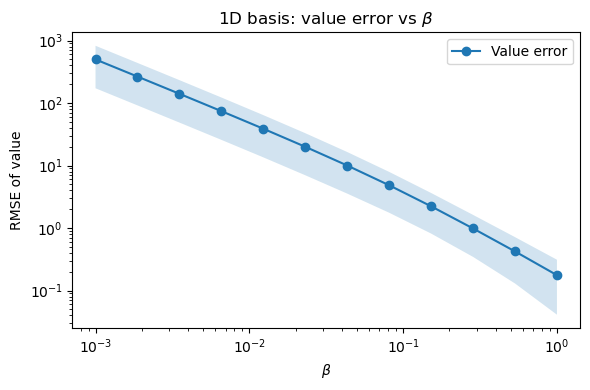

In [20]:
# ============================================================
# Value error vs beta
# ============================================================
beta_grid = np.logspace(-3, 0, 12)   # beta from 1e-3 to 1
dt_fixed = 0.1
N_fixed = 1000

results_beta = []

for beta_val in beta_grid:
    out = compute_error_for_one_setting_1d(
        beta=beta_val,
        dt=dt_fixed,
        N_sample=N_fixed,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
        n_rep=20,
        ridge=ridge,
        include_diffusion=True,   # set False if you want the no-diffusion estimator
    )
    results_beta.append(out)

df_beta = pd.DataFrame(results_beta)
#print(df_beta[["beta", "value_error_mean", "value_error_std", "theta_true"]])

plt.figure(figsize=(6, 4))
plt.plot(df_beta["beta"], df_beta["value_error_mean"], marker="o", label="Value error")
plt.fill_between(
    df_beta["beta"],
    df_beta["value_error_mean"] - df_beta["value_error_std"],
    df_beta["value_error_mean"] + df_beta["value_error_std"],
    alpha=0.2,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\beta$")
plt.ylabel("RMSE of value")
plt.title(r"1D basis: value error vs $\beta$")
plt.legend()
plt.tight_layout()
plt.show()